Auto Annotation using scArches

adapted from: https://docs.scarches.org/en/latest/hlca_map_classify.html

In [1]:
import os
import sys
import scanpy as sc
import numpy as np
import pandas as pd
import scarches as sca
import anndata as ad
from scipy import sparse
import gdown
import gzip
import shutil
import urllib.request
from pathlib import Path

 captum (see https://github.com/pytorch/captum).


In [2]:
#####
# Setting Directories
#####

# directory in which to store the reference model directory
ref_model_dir = Path.home()/"project/crc-pm/data/classifer/crc_atlas_models_minified/crc_atlas_scanvi_model/"

# directory in which to store result model of the query
surgery_model_dir = Path.home()/'project/crc-pm/result/query_model/' 

# directory in which to store the query
path_query_data = Path.home()/"project/crc-pm/result/qc/qc.h5ad"

In [3]:
adata_query_unprep = sc.read_h5ad(path_query_data)

In [4]:
# padding
adata_query = sca.models.SCANVI.prepare_query_anndata(
    adata=adata_query_unprep, reference_model=str(ref_model_dir), inplace=False
)
# Prepare obs
adata_query.obs['dataset'] = adata_query_unprep.obs['Study']
adata_query.obs['batch'] = adata_query_unprep.obs['Batch']
adata_query.obs["cell_type"] = "Unknown"

INFO     File /home/zhekai/project/crc-pm/data/classifer/crc_atlas_models_minified/crc_atlas_scanvi_model/model.pt 
         already downloaded                                                                                        
INFO     Found 98.57238158772516% reference vars in query data.                                                    


In [5]:
surgery_model = sca.models.SCANVI.load_query_data(
    adata_query,
    str(ref_model_dir),
    freeze_dropout=True,
)

INFO     File /home/zhekai/project/crc-pm/data/classifer/crc_atlas_models_minified/crc_atlas_scanvi_model/model.pt 
         already downloaded                                                                                        


In [6]:
# parameter settings copied right from tutorial
# dk what they mean
surgery_epochs = 500
early_stopping_kwargs_surgery = {
    "early_stopping_monitor": "elbo_train",
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.001,
    "plan_kwargs": {"weight_decay": 0.0},
}

In [7]:
surgery_model.registry_["setup_args"]

{'labels_key': 'cell_type',
 'unlabeled_category': 'Unknown',
 'layer': None,
 'batch_key': 'dataset',
 'size_factor_key': None,
 'categorical_covariate_keys': ['batch'],
 'continuous_covariate_keys': None,
 'use_minified': False}

In [8]:
#####
# Train model
#####
# surgery_model.train(max_epochs=surgery_epochs, **early_stopping_kwargs_surgery)
# # save model
# surgery_model.save(str(surgery_model_dir), overwrite=True)

---

In [5]:
# read
surgery_model = sca.models.SCANVI.load(surgery_model_dir, adata_query)
# get latent representation of query
adata_query_latent = sc.AnnData(surgery_model.get_latent_representation(adata_query))
# copy obs
adata_query_latent.obs = adata_query.obs.copy()
# read in ref embedding and get latent (!!! X_latent is the result of scVI, not scANVI)
adata_atlas = sc.read_h5ad(ref_model_dir/'adata.h5ad')
adata_ref_latent = sc.AnnData(
    X=adata_atlas.obsm['scanvi_latent_qzm'].copy(),
    obs=adata_atlas.obs.copy()
)

INFO     File /home/zhekai/project/crc-pm/result/query_model/model.pt already downloaded                           


In [6]:
# combine ref and query
adata_query_latent.obs["ref_or_query"] = "query"
adata_ref_latent.obs["ref_or_query"] = "ref"
# del adata_ref_latent.obs["cell_type_predicted"]
combined_emb = sc.concat(
    (adata_ref_latent, adata_query_latent), join="outer",
)
combined_emb.obs.index.is_unique

True

In [11]:
# label Transfer
knn_transformer = sca.utils.knn.weighted_knn_trainer(
    train_adata=adata_ref_latent,
    train_adata_emb="X",  # location of our joint embedding
    n_neighbors=50,
)

Weighted KNN with n_neighbors = 50 ... 

In [12]:
labels, uncert = sca.utils.knn.weighted_knn_transfer(
    query_adata=adata_query_latent,
    query_adata_emb="X", # location of our embedding, query_adata.X in this case
    label_keys="cell_type", # obs column name(s) for which to transfer labels
    knn_model=knn_transformer,
    ref_adata_obs=adata_ref_latent.obs[["cell_type"]],
    # note that adata_ref_latent has cell_type and cell_type_predicted, only send one
    # the cell_type_predicted in ref is generated by re-appling classifier to data
)

/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/scarches/utils/knn.py:130: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = (max(1 - best_prob, 0))
/home/zhekai/miniconda3/envs/scarches/lib/python3.

finished!


In [13]:
labels.rename(columns={"cell_type": "cell_type_transferred_label_unfiltered"},inplace=True,)
uncert.rename(columns={"cell_type": "cell_type_transfer_uncert"},inplace=True,)
combined_emb.obs = combined_emb.obs.rename(columns={'cell_type_predicted':'orig_cell_type_predicted'})
combined_emb.obs = combined_emb.obs.join(labels)
combined_emb.obs = combined_emb.obs.join(uncert)
# transfer data type to float
combined_emb.obs["cell_type_transfer_uncert"].dtype
combined_emb.obs["cell_type_transfer_uncert"] = pd.to_numeric(
    combined_emb.obs["cell_type_transfer_uncert"],
    errors="raise",
)
out_dir = Path.home() / "project/crc-pm/result/label-transfer"/'transferred_unfiltered.h5ad'
combined_emb.write_h5ad(str(out_dir))

---

In [14]:
combined_emb = sc.read_h5ad(Path.home() / "project/crc-pm/result/label-transfer"/'transferred_unfiltered.h5ad')

In [15]:
combined_emb.obs['cell_type_transferred_label_unfiltered'] = (combined_emb.obs['cell_type_transferred_label_unfiltered'].cat.add_categories(['Unknown']))

uncertainty_threshold = 0.2
combined_emb.obs['cell_type_transferred_label_filtered'] = combined_emb.obs['cell_type_transferred_label_unfiltered'].mask(
    combined_emb.obs['cell_type_transfer_uncert'] > uncertainty_threshold, 'Unknown')

print(np.round(
    sum(combined_emb.obs['cell_type_transferred_label_filtered'] =='Unknown')/combined_emb[combined_emb.obs['ref_or_query']=='query'].n_obs*100
    ,2))

39.59


In [16]:
combined_emb.obs.loc[
    combined_emb.obs['ref_or_query'] == 'query',
    'cell_type_transfer_uncert'
].describe()

count    340545.000000
mean          0.190994
std           0.185850
min           0.000000
25%           0.020000
50%           0.139652
75%           0.339696
max           0.879949
Name: cell_type_transfer_uncert, dtype: float64

In [17]:
combined_emb.obs.loc[
    combined_emb.obs['ref_or_query'] == 'query',
    'cell_type_transfer_uncert'
].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

0.00    0.000000
0.25    0.020000
0.50    0.139652
0.75    0.339696
0.90    0.479980
0.95    0.539978
0.99    0.640082
1.00    0.879949
Name: cell_type_transfer_uncert, dtype: float64

In [18]:
sc.pp.neighbors(combined_emb, n_neighbors=30)
sc.tl.umap(combined_emb)

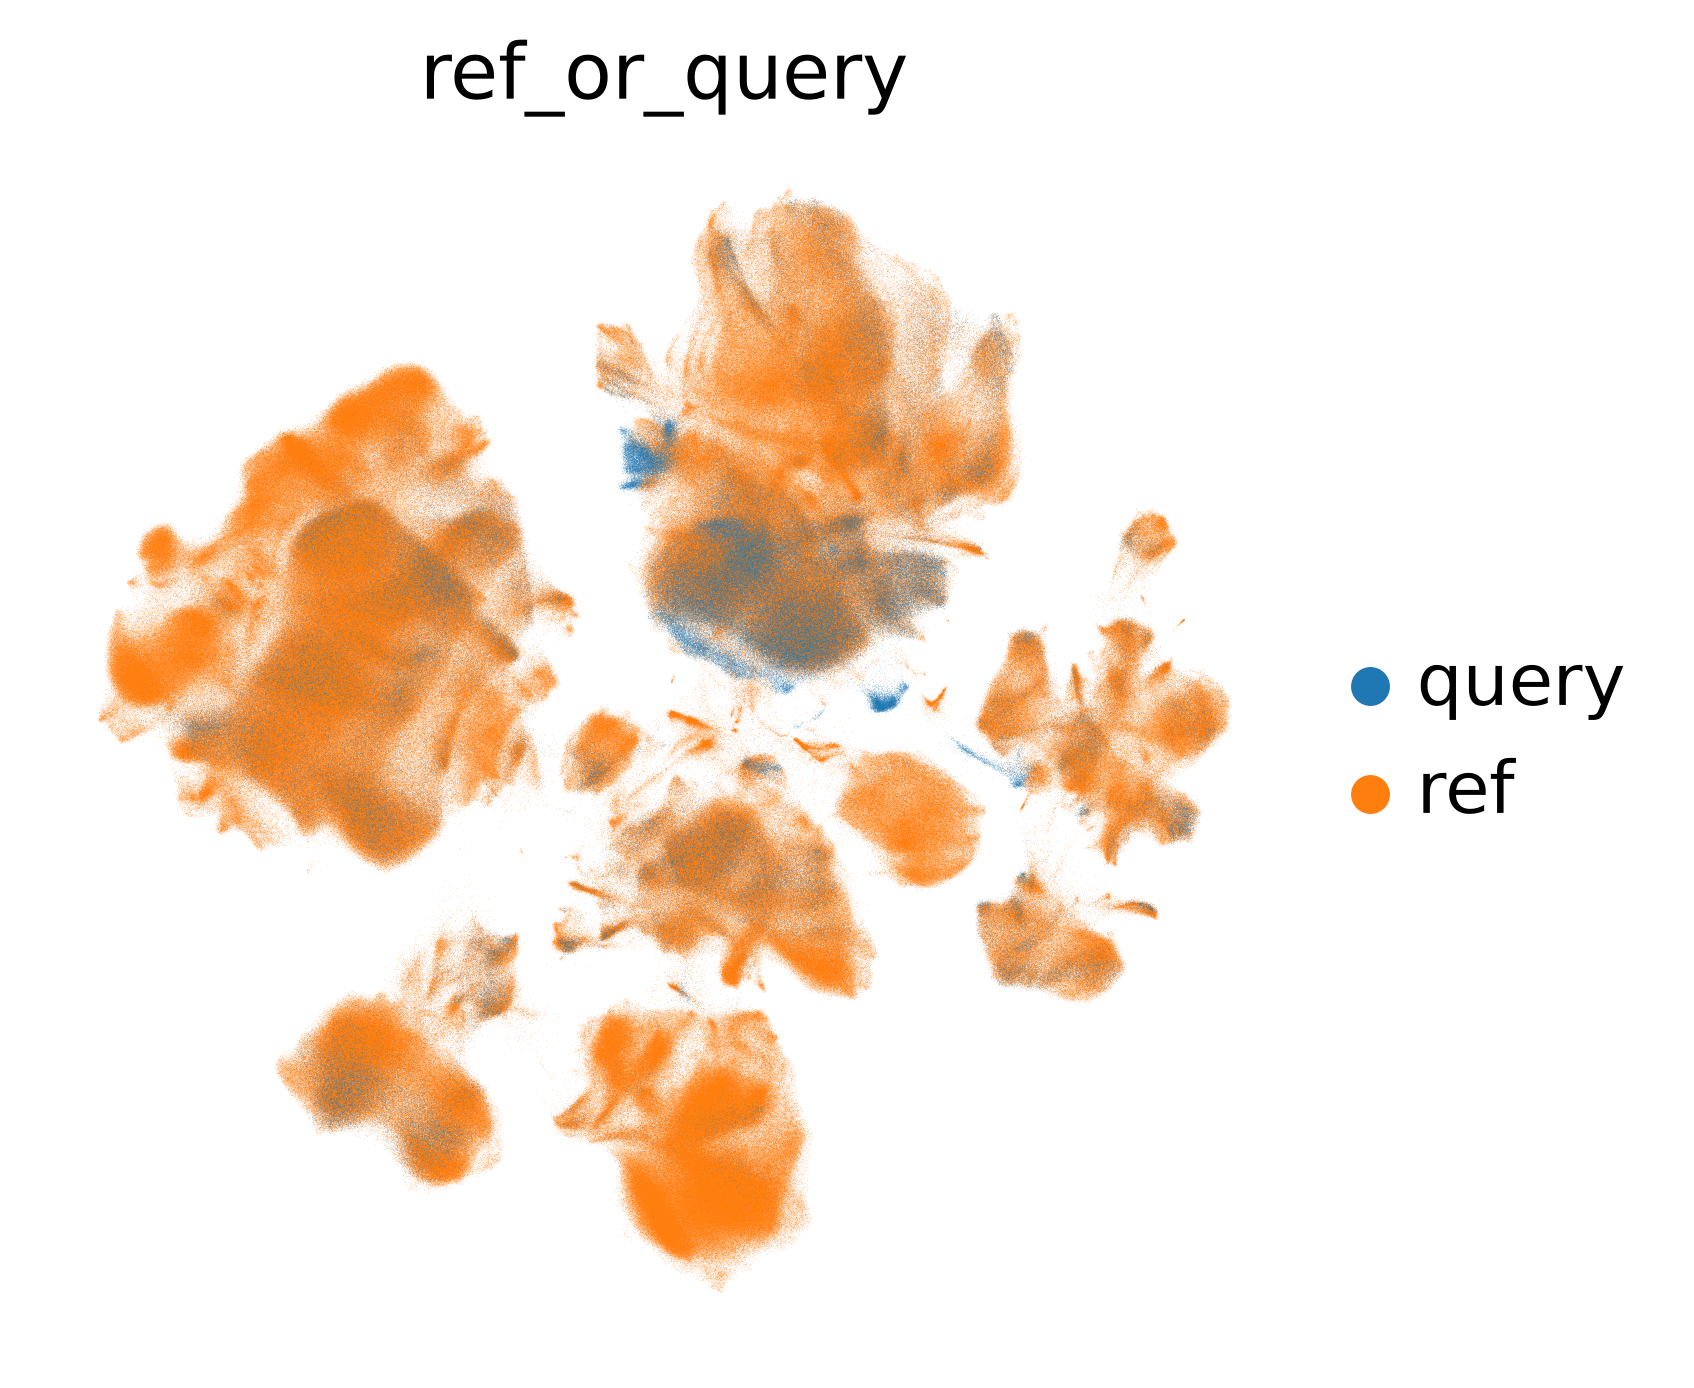

In [19]:
sc.pl.umap(combined_emb, color="ref_or_query", frameon=False, wspace=0.6)

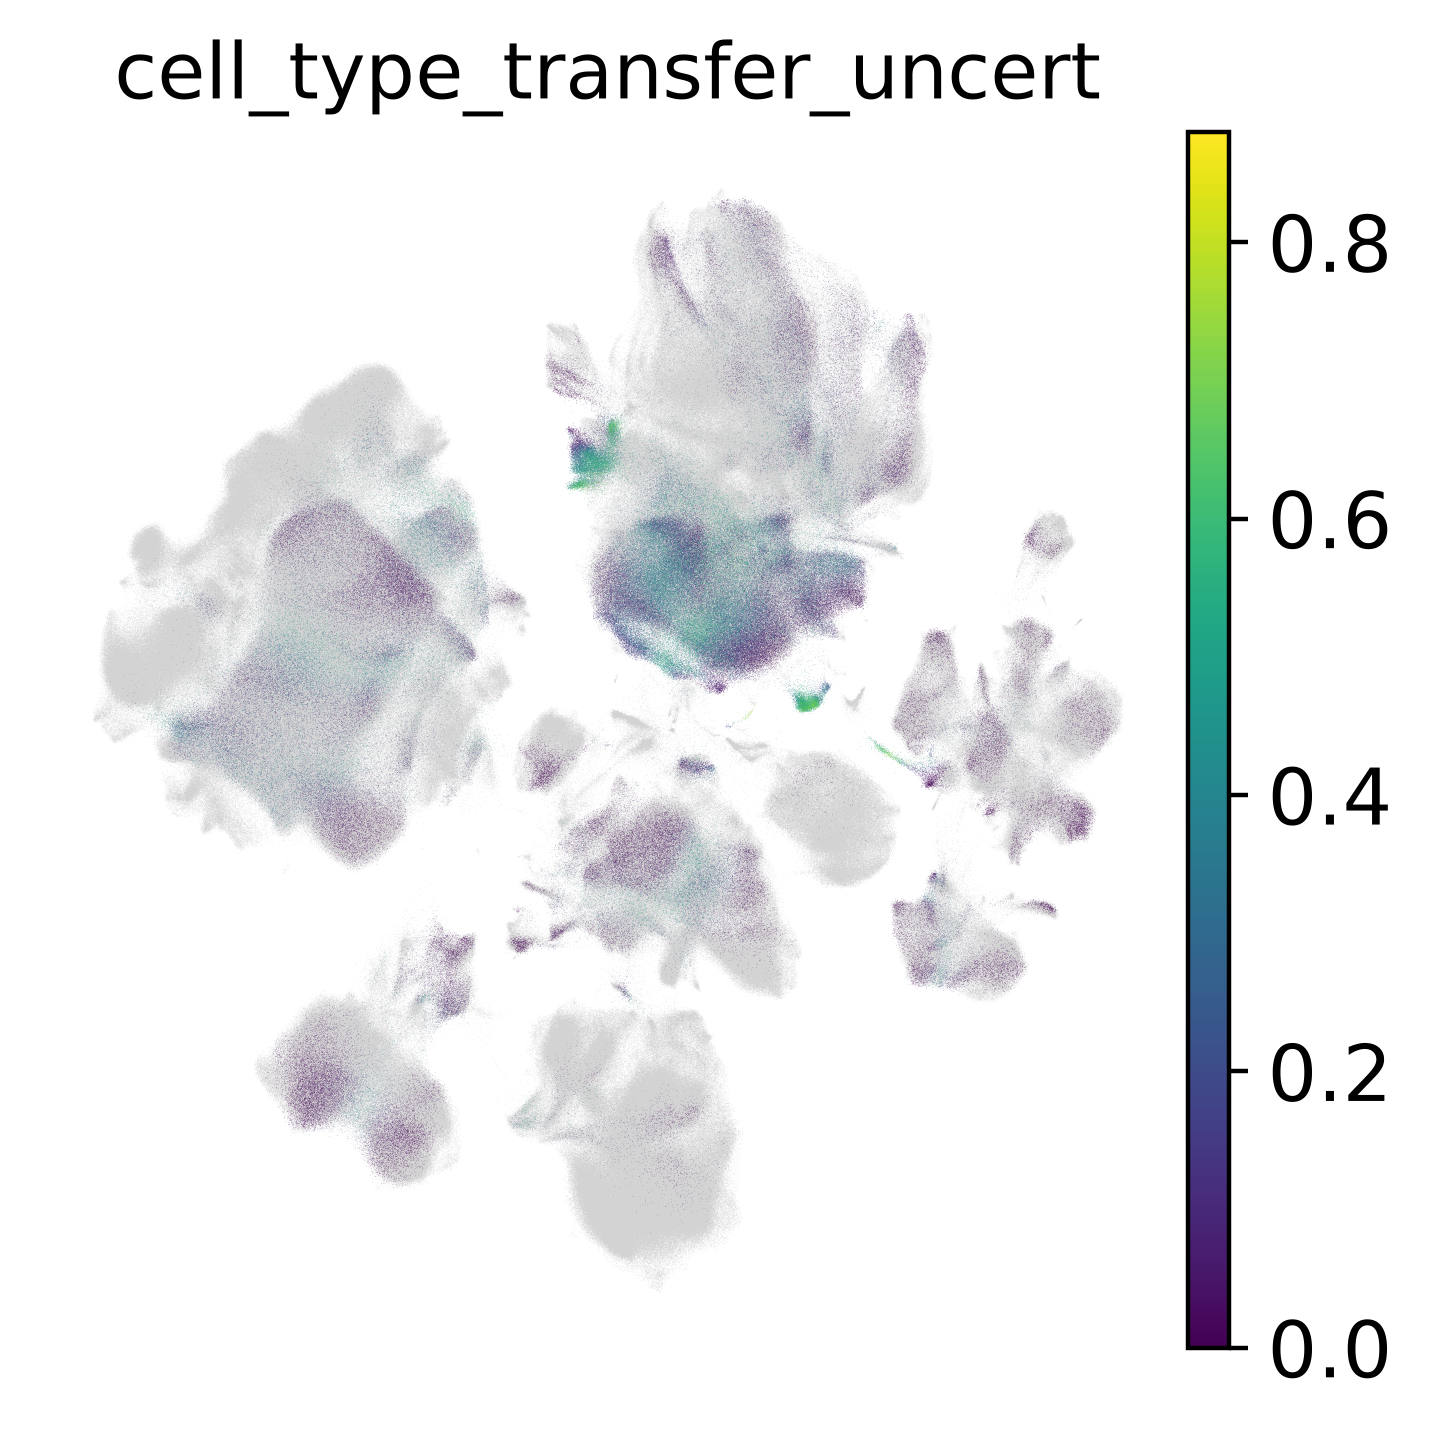

In [20]:
sc.pl.umap(
    combined_emb,
    color='cell_type_transfer_uncert',
    frameon=False,
)

In [ ]:
out_dir = Path.home() / "project/crc-pm/result/label-transfer"/'transferred.h5ad'
combined_emb.write_h5ad(str(out_dir))

In [ ]:
out_dir = Path.home() / "project/crc-pm/result/label-transfer"/'latent_repr.h5ad'
adata_query_latent.write_h5ad(str(out_dir))